# LC Improvement Training

This notebook follows the same shape as `experiment.ipynb`, but trains LC as an improvement policy. The model starts from existing LC routes in `examples/lc_results`, revisits every route, and learns typed actions: extend, trim start, trim end, halt.

## 1. Global Setup & Paths

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
import importlib
import sys
from pathlib import Path

import torch
from hydra import compose, initialize_config_dir

ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "pyproject.toml").exists():
    ROOT_DIR = ROOT_DIR.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from connectpt.routes_generator import utils as lrnu
from connectpt.routes_generator.citygraph_dataset import STOP_KEY
from connectpt.routes_generator import improvement_learning as il

il = importlib.reload(il)

from connectpt.routes_generator.improvement_learning import (
    evaluate_lc_improvement,
    load_raw_graphs_and_lc_routes,
    make_improvement_batch,
    rollout_lc_improvement,
    summarize_route_action_stats,
    train_lc_improvement,
    train_lc_improvement_cfg_ppo,
    train_lc_improvement_ppo,
)

CFG_DIR = ROOT_DIR / "connectpt" / "routes_generator" / "cfg"
RAW_GRAPHS_PATH = ROOT_DIR / "examples" / "data" / "raw_graphs_1000.pkl"
LC_RESULTS_DIR = ROOT_DIR / "examples" / "lc_results"
OUTPUT_DIR = ROOT_DIR / "examples" / "route_generator" / "lc_improvement_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Config dir: {CFG_DIR}")
print(f"Graphs:     {RAW_GRAPHS_PATH}")
print(f"LC routes:  {LC_RESULTS_DIR}")
print(f"Output:     {OUTPUT_DIR}")

/home/rk/Документы/Python Projects/connectpt/.venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config dir: /home/rk/Документы/Python Projects/connectpt/connectpt/routes_generator/cfg
Graphs:     /home/rk/Документы/Python Projects/connectpt/examples/data/raw_graphs_1000.pkl
LC routes:  /home/rk/Документы/Python Projects/connectpt/examples/lc_results
Output:     /home/rk/Документы/Python Projects/connectpt/examples/route_generator/lc_improvement_outputs


## 2. Load Graphs And Existing LC Routes

In [3]:
graphs, seed_routes = load_raw_graphs_and_lc_routes(RAW_GRAPHS_PATH, LC_RESULTS_DIR)
N_GRAPHS, N_ROUTES, SEED_ROUTE_LEN = seed_routes.shape

print(f"Loaded graphs: {len(graphs)}")
print(f"Routes shape:  {tuple(seed_routes.shape)}")
print(seed_routes[0])

Loaded graphs: 1000
Routes shape:  (1000, 12, 14)
tensor([[35, 36, 26, 27, 28, 18, 19, -1, -1, -1, -1, -1, -1, -1],
        [16, 15, 14, 13, 12, 11, 10, -1, -1, -1, -1, -1, -1, -1],
        [ 6,  5,  4,  3,  2,  1,  0, -1, -1, -1, -1, -1, -1, -1],
        [ 2, 12, 22, 21, 31, 32, 42, -1, -1, -1, -1, -1, -1, -1],
        [22, 23, 24, 34, 33, 43, 44, -1, -1, -1, -1, -1, -1, -1],
        [39, 29, 19,  9,  8,  7,  6, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]])


## 3. LC Route File Statistics

In [4]:
import pickle
from collections import Counter


def as_route_set(raw_routes):
    if isinstance(raw_routes, list):
        raw_routes = raw_routes[0]
    if getattr(raw_routes, "ndim", 0) == 3 and raw_routes.shape[0] == 1:
        raw_routes = raw_routes.squeeze(0)
    if not torch.is_tensor(raw_routes):
        raw_routes = torch.as_tensor(raw_routes)
    if raw_routes.ndim == 1:
        raw_routes = raw_routes.unsqueeze(0)
    return raw_routes


def describe_values(values):
    if not values:
        return "no values"
    tensor = torch.tensor(values, dtype=torch.float32)
    return (
        f"count={tensor.numel()}, "
        f"min={tensor.min().item():.0f}, "
        f"median={tensor.median().item():.0f}, "
        f"mean={tensor.mean().item():.2f}, "
        f"max={tensor.max().item():.0f}"
    )


route_files = sorted(LC_RESULTS_DIR.glob("graph_*/lc_*_routes_routes.pkl"))
route_counts = []
route_lengths = []
file_rows = []


graph_node_counts = []
graph_edge_counts = []
for graph in graphs:
    stop_data = graph[STOP_KEY]
    graph_node_counts.append(int(stop_data.num_nodes))
    if hasattr(stop_data, "edge_index") and stop_data.edge_index is not None:
        graph_edge_counts.append(int(stop_data.edge_index.shape[1]))
    elif hasattr(graph, "street_adj"):
        graph_edge_counts.append(int((graph.street_adj > 0).sum().item()))


for route_path in route_files:
    with route_path.open("rb") as file:
        routes = as_route_set(pickle.load(file))

    lengths = (routes >= 0).sum(dim=1).tolist()
    lengths = [int(length) for length in lengths]
    route_counts.append(int(routes.shape[0]))
    route_lengths.extend(lengths)

    file_rows.append(
        {
            "file": route_path.relative_to(LC_RESULTS_DIR),
            "routes": int(routes.shape[0]),
            "min_len": min(lengths) if lengths else 0,
            "mean_len": sum(lengths) / len(lengths) if lengths else 0,
            "max_len": max(lengths) if lengths else 0,
        }
    )

print(f"Route files:  {len(route_files)}")
print(f"Total routes: {sum(route_counts)}")
print(f"Routes/file:  {describe_values(route_counts)}")
print(f"Route length: {describe_values(route_lengths)}")
print(f"Graph nodes:  {describe_values(graph_node_counts)}")
if graph_edge_counts:
    print(f"Graph edges:  {describe_values(graph_edge_counts)}")

print("\nGraph node count distribution:")
for n_nodes, n_graphs_with_size in sorted(Counter(graph_node_counts).items()):
    print(f"  {n_nodes} nodes: {n_graphs_with_size} graphs")

print("\nRoutes per file distribution:")
for n_routes, n_files in sorted(Counter(route_counts).items()):
    print(f"  {n_routes} routes: {n_files} files")

print("\nRoute length distribution:")
for route_len, n_routes in sorted(Counter(route_lengths).items()):
    print(f"  length {route_len}: {n_routes} routes")

print("\nFirst 10 files:")
for row in file_rows[:10]:
    print(
        f"  {row['file']}: routes={row['routes']}, "
        f"len min/mean/max={row['min_len']}/{row['mean_len']:.2f}/{row['max_len']}"
    )

Route files:  1000
Total routes: 9000
Routes/file:  count=1000, min=6, median=8, mean=9.00, max=12
Route length: count=9000, min=3, median=9, mean=8.93, max=14
Graph nodes:  count=1000, min=50, median=50, mean=50.00, max=50
Graph edges:  count=1000, min=2450, median=2450, mean=2450.00, max=2450

Graph node count distribution:
  50 nodes: 1000 graphs

Routes per file distribution:
  6 routes: 250 files
  8 routes: 250 files
  10 routes: 250 files
  12 routes: 250 files

Route length distribution:
  length 3: 1 routes
  length 4: 137 routes
  length 5: 211 routes
  length 6: 250 routes
  length 7: 1652 routes
  length 8: 1641 routes
  length 9: 1350 routes
  length 10: 2398 routes
  length 11: 434 routes
  length 12: 559 routes
  length 13: 135 routes
  length 14: 232 routes

First 10 files:
  graph_0000/lc_lc_graph_0000_routes_routes.pkl: routes=6, len min/mean/max=7/7.00/7
  graph_0001/lc_lc_graph_0001_routes_routes.pkl: routes=6, len min/mean/max=6/6.67/7
  graph_0002/lc_lc_graph_0002

## 4. Visualize One Training Graph

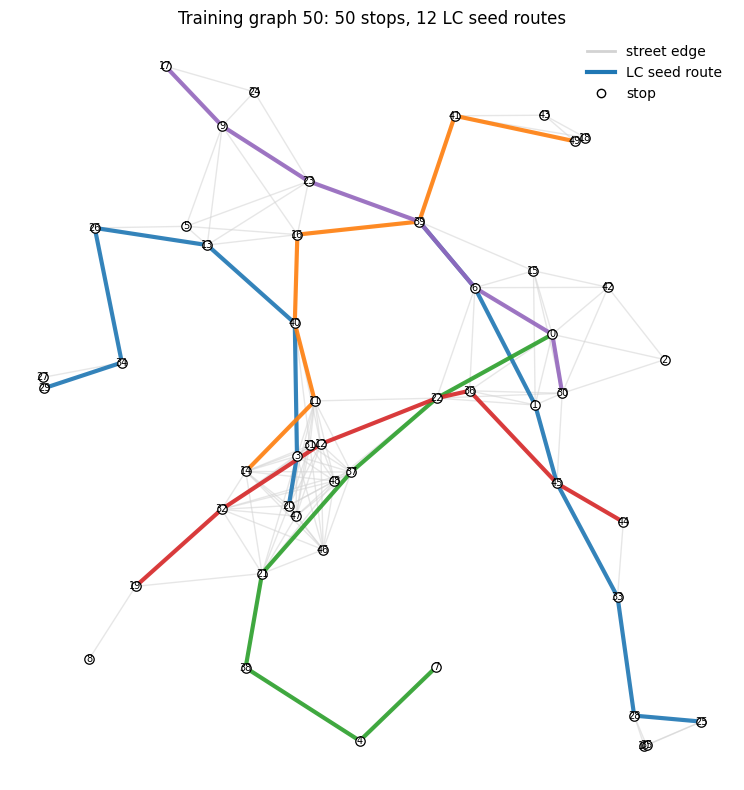

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from connectpt.routes_generator.citygraph_dataset import STOP_KEY

GRAPH_IDX = 50
graph = graphs[GRAPH_IDX]
routes = seed_routes[GRAPH_IDX]

coords = graph[STOP_KEY].pos.detach().cpu().numpy()
street_adj = graph.street_adj.detach().cpu().numpy()
n_nodes = coords.shape[0]

fig, ax = plt.subplots(figsize=(8, 8))

for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        if np.isfinite(street_adj[i, j]) or np.isfinite(street_adj[j, i]):
            ax.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color="lightgray",
                linewidth=1.0,
                alpha=0.55,
                zorder=1,
            )

route_colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(routes))))
for route_idx, route_tensor in enumerate(routes):
    route = [int(node) for node in route_tensor.detach().cpu().tolist()]
    route = [node for node in route if 0 <= node < n_nodes]
    if len(route) < 2:
        continue

    color = route_colors[route_idx % len(route_colors)]
    for start, end in zip(route[:-1], route[1:]):
        ax.plot(
            [coords[start, 0], coords[end, 0]],
            [coords[start, 1], coords[end, 1]],
            color=color,
            linewidth=3.0,
            alpha=0.9,
            solid_capstyle="round",
            zorder=3,
        )
    ax.scatter(
        coords[route, 0],
        coords[route, 1],
        color=color,
        s=32,
        edgecolor="white",
        linewidth=0.8,
        zorder=4,
    )

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=46,
    facecolor="white",
    edgecolor="black",
    linewidth=0.9,
    zorder=5,
)
for node_idx, (x_coord, y_coord) in enumerate(coords):
    ax.text(
        x_coord,
        y_coord,
        str(node_idx),
        fontsize=7,
        ha="center",
        va="center",
        zorder=6,
    )

legend_items = [
    Line2D([0], [0], color="lightgray", linewidth=2, label="street edge"),
    Line2D([0], [0], color=route_colors[0], linewidth=3, label="LC seed route"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        markerfacecolor="white",
        linewidth=0,
        label="stop",
    ),
]
ax.legend(handles=legend_items, loc="upper right", frameon=False)
ax.set_title(
    f"Training graph {GRAPH_IDX}: {n_nodes} stops, {len(routes)} LC seed routes"
)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()

## 5. Configure Trim LC Model

In [6]:
import numpy as np
import pandas as pd

MIN_ROUTE_LEN = 2
MAX_ROUTE_LEN = 14
TARGET_N_ROUTES = 12  # LC seeds have 3 routes; extra slots are empty -1 routes
MAX_ROUTE_EDIT_STEPS = 2 * MAX_ROUTE_LEN
BATCH_SIZE = 16  # cfg.batch_size=512 is too large for improvement PPO rollout states
N_EPOCHS = 10
TRAIN_FRACTION = 0.9
SPLIT_SEED = 0
FORCE_NONHALT_FIRST_STEP = False
TRAINING_ALGORITHM = "cfg_ppo_improvement"  # "cfg_ppo_improvement", "ppo_improvement", or "policy_gradient"
MAX_ROLLOUT_SAMPLES = 4096  # guard: BATCH_SIZE * PPO_HORIZON must stay below this
SUMMARY_PATH = LC_RESULTS_DIR / "all_results_summary.csv"
SPLIT_STRATIFY_COLUMNS = [
    "n_routes",
    "max_route_len",
    "demand_time_weight",
    "route_time_weight",
    "median_connectivity_weight",
]


def load_lc_route_metadata(summary_path, n_graphs):
    metadata = pd.DataFrame({"graph_index": np.arange(n_graphs, dtype=np.int64)})
    if not summary_path.exists():
        print(f"Summary file not found: {summary_path}; using an unstratified split.")
        return metadata

    summary_df = pd.read_csv(summary_path)
    if "graph_index" not in summary_df.columns:
        raise ValueError(f"Expected graph_index column in {summary_path}")

    summary_df = summary_df.drop_duplicates("graph_index").copy()
    summary_df["graph_index"] = summary_df["graph_index"].astype(int)
    metadata = metadata.merge(summary_df, on="graph_index", how="left")
    return metadata


def make_stratified_split_indices(metadata_df, train_fraction, seed, stratify_columns):
    rng = np.random.default_rng(seed)
    split_df = metadata_df.copy()

    for column in stratify_columns:
        if column not in split_df.columns:
            split_df[column] = "all"

    for column in stratify_columns:
        if pd.api.types.is_numeric_dtype(split_df[column]):
            split_df[column] = split_df[column].fillna(-1)
            if split_df[column].dtype.kind == "f":
                split_df[column] = split_df[column].round(6)
        else:
            split_df[column] = split_df[column].fillna("missing")

    train_indices = []
    val_indices = []
    for _, group_df in split_df.groupby(stratify_columns, dropna=False, sort=True):
        group_indices = group_df["graph_index"].to_numpy(dtype=np.int64, copy=True)
        rng.shuffle(group_indices)

        if len(group_indices) <= 1:
            n_train = len(group_indices)
        else:
            n_train = int(round(train_fraction * len(group_indices)))
            n_train = max(1, min(n_train, len(group_indices) - 1))

        train_indices.extend(group_indices[:n_train].tolist())
        val_indices.extend(group_indices[n_train:].tolist())

    train_indices = np.asarray(train_indices, dtype=np.int64)
    val_indices = np.asarray(val_indices, dtype=np.int64)
    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    return (
        torch.as_tensor(train_indices, dtype=torch.long),
        torch.as_tensor(val_indices, dtype=torch.long),
    )


with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
    cfg = compose(
        config_name="ppo_50nodes.yaml",
        overrides=[
            "model=bestsofar_feb2023_trim",
            "model.route_generator.kwargs.serial_halting=True",
            "++run_name=lc_improvement_trim",
            "++experiment.logdir=null",
        ],
    )

CFG_BATCH_SIZE = int(cfg.batch_size)
PPO_N_ITERATIONS = int(cfg.ppo.n_iterations)
PPO_VAL_PERIOD = int(cfg.ppo.val_period)
PPO_HORIZON = int(cfg.ppo.horizon)
PPO_EPOCHS = int(cfg.ppo.n_epochs)
PPO_MINIBATCH_SIZE = int(cfg.ppo.minibatch_size)
PPO_CLIP_EPSILON = float(cfg.ppo.epsilon)

device, run_name, _, cost_obj, model = lrnu.process_standard_experiment_cfg(
    cfg,
    run_name_prefix="improvement_",
)
cost_obj.ignore_stops_oob = True  # keep the unstarted-route penalty for extra empty slots

LC_ROUTE_METADATA = load_lc_route_metadata(SUMMARY_PATH, N_GRAPHS)
TRAIN_INDICES, VAL_INDICES = make_stratified_split_indices(
    LC_ROUTE_METADATA,
    train_fraction=TRAIN_FRACTION,
    seed=SPLIT_SEED,
    stratify_columns=SPLIT_STRATIFY_COLUMNS,
)
BEST_MODEL_PATH = OUTPUT_DIR / f"{run_name}.pt"
VAL_ROUTES_PATH = OUTPUT_DIR / f"{run_name}_val_routes.pt"

split_balance = LC_ROUTE_METADATA.copy()
split_balance["split"] = "val"
split_balance.loc[
    split_balance["graph_index"].isin(TRAIN_INDICES.tolist()),
    "split",
] = "train"

balance_columns = [
    column for column in SPLIT_STRATIFY_COLUMNS
    if column in split_balance.columns
]
if balance_columns:
    balance_df = (
        split_balance
        .groupby(balance_columns + ["split"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .sort_values(balance_columns)
        .reset_index(drop=True)
    )
    display(balance_df)

print(f"Device: {device}")
print(f"Run:    {run_name}")
print(f"Model:  {type(model).__name__}")
print(f"Trim actions enabled: {getattr(model, 'supports_trim_actions', False)}")
print(f"Serial halting: {getattr(model, 'serial_halting', None)}")
print(f"Training algorithm: {TRAINING_ALGORITHM}")
print(f"Config diff_reward: {cfg.diff_reward}")
print(f"Config batch size: {CFG_BATCH_SIZE}")
print(f"Reward scale: {cfg.reward_scale}")
print(f"Discount rate: {cfg.discount_rate}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Seed routes per graph: {seed_routes.shape[1]}")
print(f"Target route slots: {TARGET_N_ROUTES}")
print(f"Empty route slots: {max(TARGET_N_ROUTES - seed_routes.shape[1], 0) if TARGET_N_ROUTES is not None else 0}")
print(f"PPO iterations: {PPO_N_ITERATIONS}")
print(f"PPO val period: {PPO_VAL_PERIOD}")
print(f"PPO horizon: {PPO_HORIZON}")
print(f"PPO epochs: {PPO_EPOCHS}")
print(f"PPO minibatch size: {PPO_MINIBATCH_SIZE}")
print(f"PPO clip epsilon: {PPO_CLIP_EPSILON}")
print(f"Max route edit steps: {MAX_ROUTE_EDIT_STEPS}")
print(f"Rollout samples: {BATCH_SIZE * PPO_HORIZON} / {MAX_ROLLOUT_SAMPLES}")
print(f"Split stratify columns: {balance_columns}")
print(f"Train graphs: {len(TRAIN_INDICES)}")
print(f"Val graphs:   {len(VAL_INDICES)}")
print(f"Checkpoint:   {BEST_MODEL_PATH}")


Device: cuda
Run:    improvement_lc_improvement_trim
Model:  TrimPathCombiningRouteGenerator
Trim actions enabled: True
Serial halting: True
Training algorithm: cfg_ppo_improvement
Config diff_reward: True
Config batch size: 512
Reward scale: 1.0
Discount rate: 0.95
Batch size: 16
Seed routes per graph: 12
Target route slots: 12
Empty route slots: 0
PPO iterations: 200
PPO val period: 10
PPO horizon: 200
PPO epochs: 1
PPO minibatch size: 32
PPO clip epsilon: 0.2
Max route edit steps: 28
Rollout samples: 3200 / 4096
Train graphs: 900
Val graphs:   100
Checkpoint:   /home/rk/Документы/Python Projects/connectpt/examples/route_generator/lc_improvement_outputs/improvement_lc_improvement_trim.pt


## 6. PPO Improvement Training

По умолчанию этот ноутбук использует `TRAINING_ALGORITHM = "cfg_ppo_improvement"`. Это отдельный PPO-режим для задачи improvement: он стартует не с пустой маршрутной сети, а с уже готовых LC routes из `raw_graphs_1000.pkl` и `examples/lc_results`.

Чем обычный PPO из `experiment.ipynb` отличается от PPO improvement:

- Обычный PPO строит route set с нуля: empty state -> route 1 -> route 2 -> ... -> done.
- Обычный rollout живет в одном последовательном `RouteGenBatchState`, где награда обычно считается как `diff_reward`: насколько стоимость изменилась после очередного добавления маршрута.
- В обычном PPO используется полный PPO loop из `inductive_route_learning.py`: rollout horizon, clipped objective, value baseline / GAE и minibatches.
- PPO improvement получает уже существующие маршруты и редактирует каждый route slot в контексте остальных маршрутов этой же сети.
- Для improvement действия типизированы: `extend`, `trim_start`, `trim_end`, `halt`.
- `cfg_ppo_improvement` переносит эти же PPO-механики в improvement: `cfg.ppo.horizon`, `cfg.ppo.n_epochs`, `cfg.ppo.minibatch_size`, `cfg.ppo.epsilon`, `cfg.ppo.use_gae`, `cfg.ppo.gae_lambda`, `discount_rate`, `reward_scale`, `entropy_weight`, `lr`, `decay` и `optimizer` берутся из выбранного `ppo_20nodes.yaml` или `ppo_50nodes.yaml`.
- Флаг `cfg.diff_reward` теперь тоже используется: при `true` reward на edit step равен `cost_before_action - cost_after_action`, как в обычном PPO; при `false` reward дается только на terminal halt как отрицательная итоговая стоимость.
- В ноутбуке `BATCH_SIZE` намеренно переопределен на небольшое значение. `cfg.batch_size` в `ppo_50nodes.yaml` равен 512, а для improvement PPO это слишком много, потому что rollout хранит тяжелые snapshots `RouteGenBatchState`.
- `max_route_edit_steps` ограничивает число edit actions на один маршрут, чтобы trim/extend не могли уйти в бесконечный цикл.


## 7. Train PPO Improvement Policy

In [7]:
common_train_kwargs = dict(
    model=model,
    cost_obj=cost_obj,
    graphs=graphs,
    seed_routes=seed_routes,
    device=device,
    output_dir=OUTPUT_DIR,
    run_name=run_name,
    train_fraction=TRAIN_FRACTION,
    batch_size=BATCH_SIZE,
    min_route_len=MIN_ROUTE_LEN,
    max_route_len=MAX_ROUTE_LEN,
    seed=SPLIT_SEED,
    force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
    target_n_routes=TARGET_N_ROUTES,
    train_indices=TRAIN_INDICES,
    val_indices=VAL_INDICES,
    best_model_path=BEST_MODEL_PATH,
)

if TRAINING_ALGORITHM == "cfg_ppo_improvement":
    train_result = train_lc_improvement_cfg_ppo(
        **common_train_kwargs,
        cfg=cfg,
        n_iterations=PPO_N_ITERATIONS,
        val_period=PPO_VAL_PERIOD,
        horizon=PPO_HORIZON,
        ppo_epochs=PPO_EPOCHS,
        minibatch_size=PPO_MINIBATCH_SIZE,
        max_rollout_samples=MAX_ROLLOUT_SAMPLES,
    )
elif TRAINING_ALGORITHM == "ppo_improvement":
    train_result = train_lc_improvement_ppo(
        **common_train_kwargs,
        n_epochs=N_EPOCHS,
        ppo_epochs=PPO_EPOCHS,
        clip_epsilon=PPO_CLIP_EPSILON,
    )
elif TRAINING_ALGORITHM == "policy_gradient":
    train_result = train_lc_improvement(
        **common_train_kwargs,
        n_epochs=N_EPOCHS,
    )
else:
    raise ValueError(f"Unknown TRAINING_ALGORITHM: {TRAINING_ALGORITHM}")

print(f"Best model: {BEST_MODEL_PATH}")

import pandas as pd

action_history = pd.DataFrame(train_result["history"])
action_columns = [
    "epoch",
    "train_action_extend_count",
    "train_action_trim_start_count",
    "train_action_trim_end_count",
    "train_action_halt_count",
    "train_action_total_count",
    "train_action_avg_actions_per_route",
    "train_action_extend_rate",
    "train_action_trim_rate",
    "train_action_halt_rate",
]
ppo_columns = [
    "diff_reward",
    "ppo_horizon",
    "ppo_epochs",
    "ppo_minibatch_size",
    "train_reward_mean",
    "train_return_mean",
    "train_active_sample_count",
    "train_ppo_ratio_mean",
    "train_ppo_clip_fraction",
    "train_ppo_objective",
]
display_columns = action_columns + [
    col for col in ppo_columns if col in action_history.columns
]
display(action_history[display_columns])

feature norm:  25%|██▌       | 1/4 [00:13<00:39, 13.03s/it]/home/rk/Документы/Python Projects/connectpt/connectpt/routes_generator/models.py:603: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  x_var = xx.var(0).detach()
cfg ppo improvement:   0%|          | 1/200 [01:20<4:26:43, 80.42s/it, reward=0.007, delta=0.077, ratio=0.996, clip=13.40%]

cfg_ppo_iter=001 reward=0.0069 train_delta=0.0768 val_delta=nan ratio=0.996 clip=13.40% actions=ext:822 trim_s:108 trim_e:114 halt:561 avg_steps=11.15 eval=False


cfg ppo improvement:   1%|          | 2/200 [02:39<4:22:30, 79.55s/it, reward=0.017, delta=0.141, ratio=1.006, clip=15.17%]

cfg_ppo_iter=002 reward=0.0170 train_delta=0.1407 val_delta=nan ratio=1.006 clip=15.17% actions=ext:726 trim_s:69 trim_e:66 halt:596 avg_steps=8.28 eval=False


cfg ppo improvement:   2%|▏         | 3/200 [03:57<4:19:08, 78.93s/it, reward=0.015, delta=0.125, ratio=0.991, clip=18.28%]

...

cfg ppo improvement: 100%|█████████▉| 199/200 [5:44:48<01:31, 91.62s/it, reward=0.091, delta=0.842, ratio=0.995, clip=11.62%]

cfg_ppo_iter=199 reward=0.0906 train_delta=0.8416 val_delta=-1.1906 ratio=0.995 clip=11.62% actions=ext:852 trim_s:83 trim_e:65 halt:635 avg_steps=9.29 eval=False


cfg ppo improvement: 100%|██████████| 200/200 [5:51:44<00:00, 105.52s/it, reward=0.079, delta=0.790, ratio=0.991, clip=12.03%]

cfg_ppo_iter=200 reward=0.0792 train_delta=0.7905 val_delta=-0.1307 ratio=0.991 clip=12.03% actions=ext:842 trim_s:92 trim_e:85 halt:578 avg_steps=9.98 eval=True
Best model: /home/rk/Документы/Python Projects/connectpt/examples/route_generator/lc_improvement_outputs/improvement_lc_improvement_trim.pt


,epoch,train_action_extend_count,train_action_trim_start_count,train_action_trim_end_count,train_action_halt_count,train_action_total_count,train_action_avg_actions_per_route,train_action_extend_rate,train_action_trim_rate,train_action_halt_rate,diff_reward,ppo_horizon,ppo_epochs,ppo_minibatch_size,train_reward_mean,train_return_mean,train_active_sample_count,train_ppo_ratio_mean,train_ppo_clip_fraction,train_ppo_objective
0,1,822,108,114,561,1605,11.145833,0.512150,0.138318,0.349533,True,200,1,32,0.006894,0.078988,1605,0.996310,0.133956,0.002375
1,2,726,69,66,596,1457,8.278409,0.498284,0.092656,0.409060,True,200,1,32,0.016993,0.123873,1457,1.006335,0.151682,0.017623
2,3,778,53,65,674,1570,8.177083,0.495541,0.075159,0.429299,True,200,1,32,0.015312,0.121446,1570,0.990909,0.182803,0.016083
3,4,803,40,44,668,1555,8.835227,0.516399,0.054019,0.429582,True,200,1,32,0.035042,0.223957,1555,1.002089,0.180707,0.017119
4,5,775,42,33,692,1542,8.031250,0.502594,0.048638,0.448768,True,200,1,32,0.049797,0.273345,1542,0.990837,0.267834,0.018589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,877,122,101,539,1639,10.243750,0.535082,0.136059,0.328859,True,200,1,32,0.066781,0.172184,1639,1.005728,0.101891,-0.007069
196,197,792,93,105,471,1461,10.145833,0.542094,0.135524,0.322382,True,200,1,32,0.057291,0.210950,1461,0.989924,0.104795,-0.001327
197,198,849,74,92,583,1598,11.097222,0.531289,0.103880,0.364831,True,200,1,32,0.089467,0.401451,1598,1.003513,0.085160,-0.009720
198,199,852,83,65,635,1635,9.289773,0.521101,0.090520,0.388379,True,200,1,32,0.090589,0.470104,1635,0.994519,0.116208,-0.006627


## 8. Training Curves


,iteration,epoch,algorithm,target_n_routes,diff_reward,reward_scale,discount_rate,ppo_horizon,ppo_epochs,ppo_minibatch_size,...,train_action_trim_count,train_action_edit_count,train_action_extend_rate,train_action_trim_start_rate,train_action_trim_end_rate,train_action_halt_rate,train_action_trim_rate,train_action_edit_rate,train_action_avg_actions_per_route,train_changed_route_rate
0,1,1,cfg_ppo_improvement,12,True,1.0,0.95,200,1,32,...,222,1044,0.512150,0.067290,0.071028,0.349533,0.138318,0.650467,11.145833,NaN
1,2,2,cfg_ppo_improvement,12,True,1.0,0.95,200,1,32,...,135,861,0.498284,0.047358,0.045299,0.409060,0.092656,0.590940,8.278409,NaN
2,3,3,cfg_ppo_improvement,12,True,1.0,0.95,200,1,32,...,118,896,0.495541,0.033758,0.041401,0.429299,0.075159,0.570701,8.177083,NaN
3,4,4,cfg_ppo_improvement,12,True,1.0,0.95,200,1,32,...,84,887,0.516399,0.025723,0.028296,0.429582,0.054019,0.570418,8.835227,NaN
4,5,5,cfg_ppo_improvement,12,True,1.0,0.95,200,1,32,...,75,850,0.502594,0.027237,0.021401,0.448768,0.048638,0.551232,8.031250,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,196,cfg_ppo_improvement,12,True,1.0,0.95,200,1,32,...,223,1100,0.535082,0.074436,0.061623,0.328859,0.136059,0.671141,10.243750,NaN
196,197,197,cfg_ppo_improvement,12,True,1.0,0.95,200,1,32,...,198,990,0.542094,0.063655,0.071869,0.322382,0.135524,0.677618,10.145833,NaN
197,198,198,cfg_ppo_improvement,12,True,1.0,0.95,200,1,32,...,166,1015,0.531289,0.046308,0.057572,0.364831,0.103880,0.635169,11.097222,NaN
198,199,199,cfg_ppo_improvement,12,True,1.0,0.95,200,1,32,...,148,1000,0.521101,0.050765,0.039755,0.388379,0.090520,0.611621,9.289773,NaN


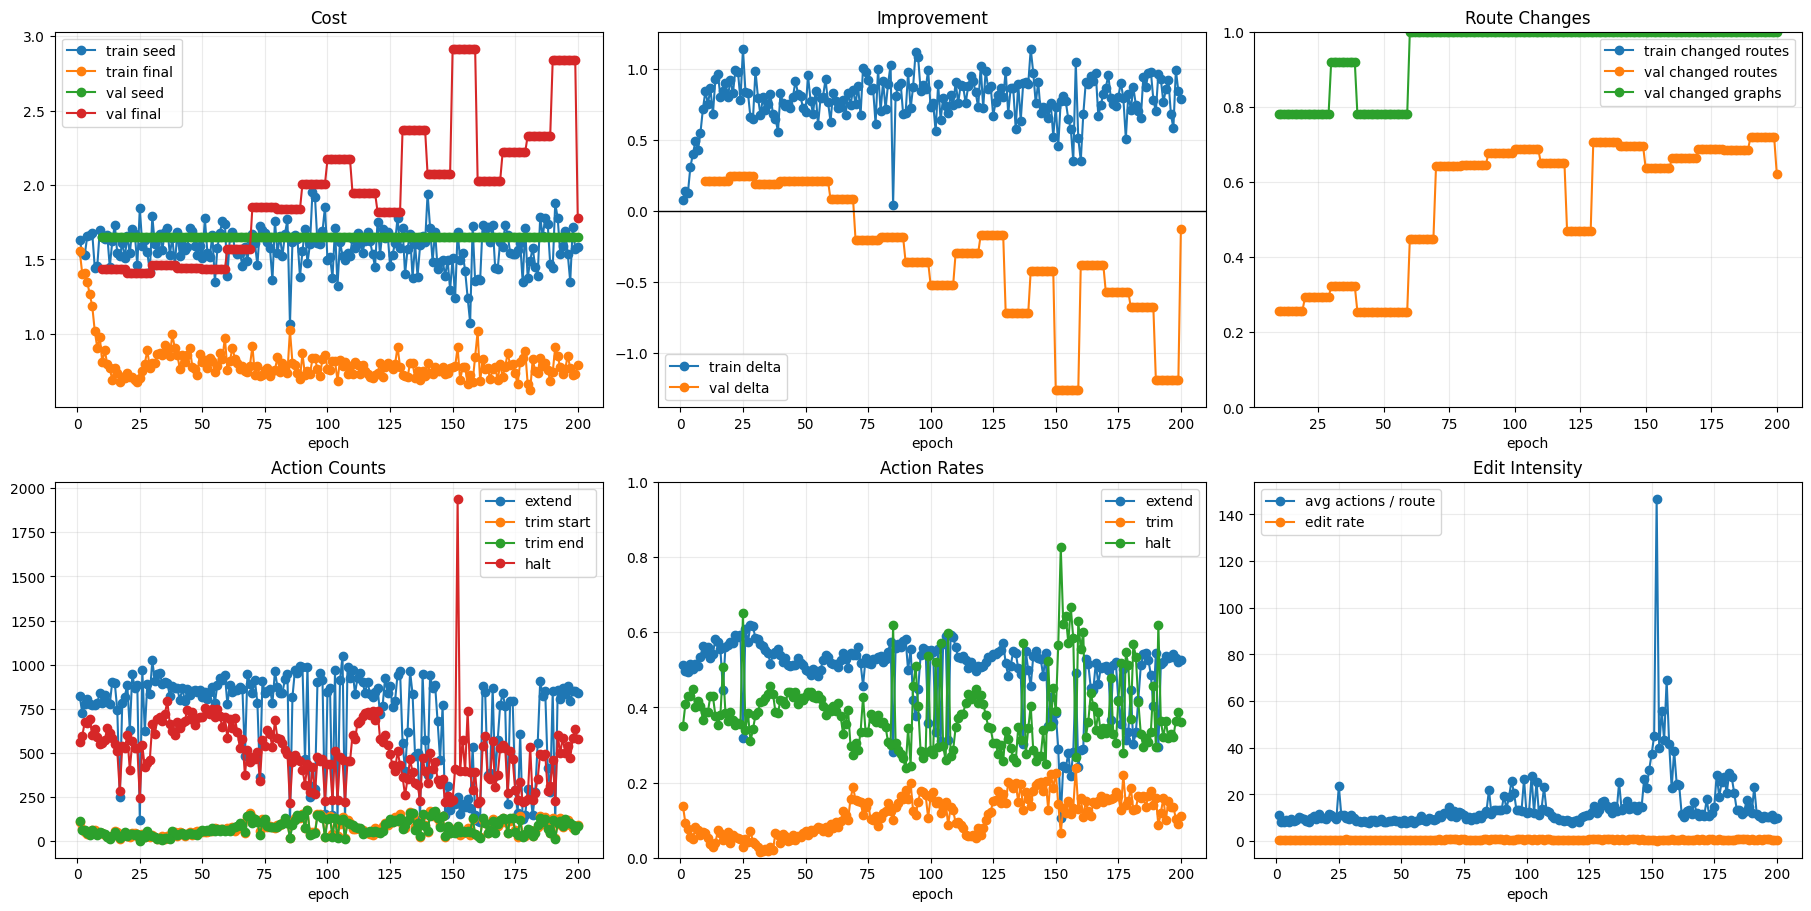

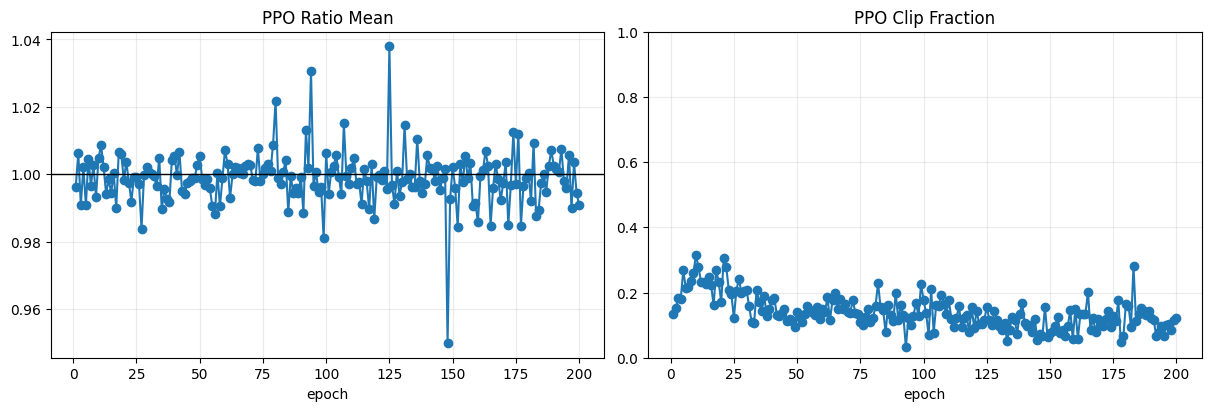

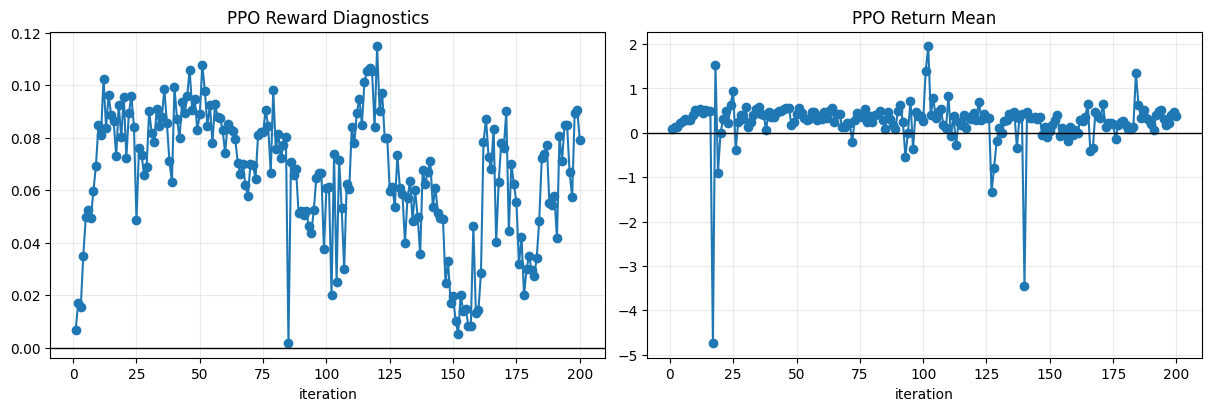

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

if "train_result" not in globals():
    raise RuntimeError("Run the training cell first so train_result is available.")

history_df = pd.DataFrame(train_result["history"])
display(history_df)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

axes[0, 0].plot(history_df["epoch"], history_df["train_seed_cost"], marker="o", label="train seed")
axes[0, 0].plot(history_df["epoch"], history_df["train_final_cost"], marker="o", label="train final")
axes[0, 0].plot(history_df["epoch"], history_df["val_seed_cost"], marker="o", label="val seed")
axes[0, 0].plot(history_df["epoch"], history_df["val_final_cost"], marker="o", label="val final")
axes[0, 0].set_title("Cost")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)

axes[0, 1].plot(history_df["epoch"], history_df["train_delta"], marker="o", label="train delta")
axes[0, 1].plot(history_df["epoch"], history_df["val_delta"], marker="o", label="val delta")
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("Improvement")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

axes[0, 2].plot(history_df["epoch"], history_df["train_changed_route_rate"], marker="o", label="train changed routes")
axes[0, 2].plot(history_df["epoch"], history_df["val_changed_route_rate"], marker="o", label="val changed routes")
axes[0, 2].plot(history_df["epoch"], history_df["val_changed_graph_rate"], marker="o", label="val changed graphs")
axes[0, 2].set_title("Route Changes")
axes[0, 2].set_xlabel("epoch")
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.25)

axes[1, 0].plot(history_df["epoch"], history_df["train_action_extend_count"], marker="o", label="extend")
axes[1, 0].plot(history_df["epoch"], history_df["train_action_trim_start_count"], marker="o", label="trim start")
axes[1, 0].plot(history_df["epoch"], history_df["train_action_trim_end_count"], marker="o", label="trim end")
axes[1, 0].plot(history_df["epoch"], history_df["train_action_halt_count"], marker="o", label="halt")
axes[1, 0].set_title("Action Counts")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot(history_df["epoch"], history_df["train_action_extend_rate"], marker="o", label="extend")
axes[1, 1].plot(history_df["epoch"], history_df["train_action_trim_rate"], marker="o", label="trim")
axes[1, 1].plot(history_df["epoch"], history_df["train_action_halt_rate"], marker="o", label="halt")
axes[1, 1].set_title("Action Rates")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.25)

axes[1, 2].plot(history_df["epoch"], history_df["train_action_avg_actions_per_route"], marker="o", label="avg actions / route")
axes[1, 2].plot(history_df["epoch"], history_df["train_action_edit_rate"], marker="o", label="edit rate")
axes[1, 2].set_title("Edit Intensity")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.25)

plt.show()

if {"train_ppo_ratio_mean", "train_ppo_clip_fraction"}.issubset(history_df.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    axes[0].plot(history_df["epoch"], history_df["train_ppo_ratio_mean"], marker="o")
    axes[0].axhline(1.0, color="black", linewidth=1)
    axes[0].set_title("PPO Ratio Mean")
    axes[0].set_xlabel("epoch")
    axes[0].grid(alpha=0.25)

    axes[1].plot(history_df["epoch"], history_df["train_ppo_clip_fraction"], marker="o")
    axes[1].set_title("PPO Clip Fraction")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.25)

    plt.show()

if {"train_reward_mean", "train_return_mean"}.issubset(history_df.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    axes[0].plot(history_df["epoch"], history_df["train_reward_mean"], marker="o")
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("PPO Reward Diagnostics")
    axes[0].set_xlabel("iteration")
    axes[0].grid(alpha=0.25)

    axes[1].plot(history_df["epoch"], history_df["train_return_mean"], marker="o")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("PPO Return Mean")
    axes[1].set_xlabel("iteration")
    axes[1].grid(alpha=0.25)

    plt.show()


## 9. Final Validation And Route Export

In [9]:
import pandas as pd

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(f"Train the model first or set BEST_MODEL_PATH: {BEST_MODEL_PATH}")

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
val = evaluate_lc_improvement(
    model,
    cost_obj,
    graphs,
    seed_routes,
    VAL_INDICES,
    device,
    MIN_ROUTE_LEN,
    MAX_ROUTE_LEN,
    batch_size=BATCH_SIZE,
    force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
    return_action_stats=True,
    target_n_routes=TARGET_N_ROUTES,
)

routes_path = VAL_ROUTES_PATH
torch.save(val["routes"], routes_path)

action_stats = val.get("action_stats", {})
action_rows = []
for action_name in ["extend", "trim_start", "trim_end", "trim", "halt", "edit"]:
    count_key = f"{action_name}_count"
    rate_key = f"{action_name}_rate"
    if count_key not in action_stats:
        continue
    action_rows.append(
        {
            "action": action_name,
            "count": int(action_stats[count_key]),
            "rate": float(action_stats.get(rate_key, 0.0)),
        }
    )

action_stats_df = pd.DataFrame(action_rows)

print(f"Validation target routes: {val['target_n_routes']}")
print(f"Validation seed cost:  {val['seed_cost']:.4f}")
print(f"Validation final cost: {val['final_cost']:.4f}")
print(f"Validation delta:      {val['delta']:.4f}")
print(f"Win rate:              {val['win_rate']:.2%}")
print(f"Changed route rate:    {val['changed_route_rate']:.2%}")
print(f"Changed graph rate:    {val['changed_graph_rate']:.2%}")
if action_stats:
    print(f"Route plans:           {int(action_stats['route_plan_count'])}")
    print(f"Total actions:         {int(action_stats['total_count'])}")
    print(f"Avg actions / route:   {action_stats['avg_actions_per_route']:.2f}")
print(f"Routes saved to:       {routes_path}")

if not action_stats_df.empty:
    display(action_stats_df)


eval:   0%|          | 0/7 [00:00<?, ?it/s]

Validation target routes: 12
Validation seed cost:  1.6484
Validation final cost: 1.4051
Validation delta:      0.2433
Win rate:              47.00%
Changed route rate:    29.25%
Changed graph rate:    78.00%
Route plans:           1200
Total actions:         1866
Avg actions / route:   1.55
Routes saved to:       /home/rk/Документы/Python Projects/connectpt/examples/route_generator/lc_improvement_outputs/improvement_lc_improvement_trim_val_routes.pt


,action,count,rate
0,extend,635,0.340300
1,trim_start,29,0.015541
2,trim_end,2,0.001072
3,trim,31,0.016613
4,halt,1200,0.643087
5,edit,666,0.356913


## 10. Balanced One-Graph Action GIF


Graph:       94
GIF frames:  28
Seed cost:   3.7816
Final cost:  0.5305
Delta:       3.2511
Action stats: {'extend_count': 14, 'trim_start_count': 0, 'trim_end_count': 0, 'halt_count': 12, 'total_count': 26, 'route_plan_count': 12, 'trim_count': 0, 'edit_count': 14, 'extend_rate': 0.5384615384615384, 'trim_start_rate': 0.0, 'trim_end_rate': 0.0, 'halt_rate': 0.46153846153846156, 'trim_rate': 0.0, 'edit_rate': 0.5384615384615384, 'avg_actions_per_route': 2.1666666666666665}
GIF path:    /home/rk/Документы/Python Projects/connectpt/examples/route_generator/lc_improvement_outputs/improvement_lc_improvement_trim_graph_94_balanced_actions.gif


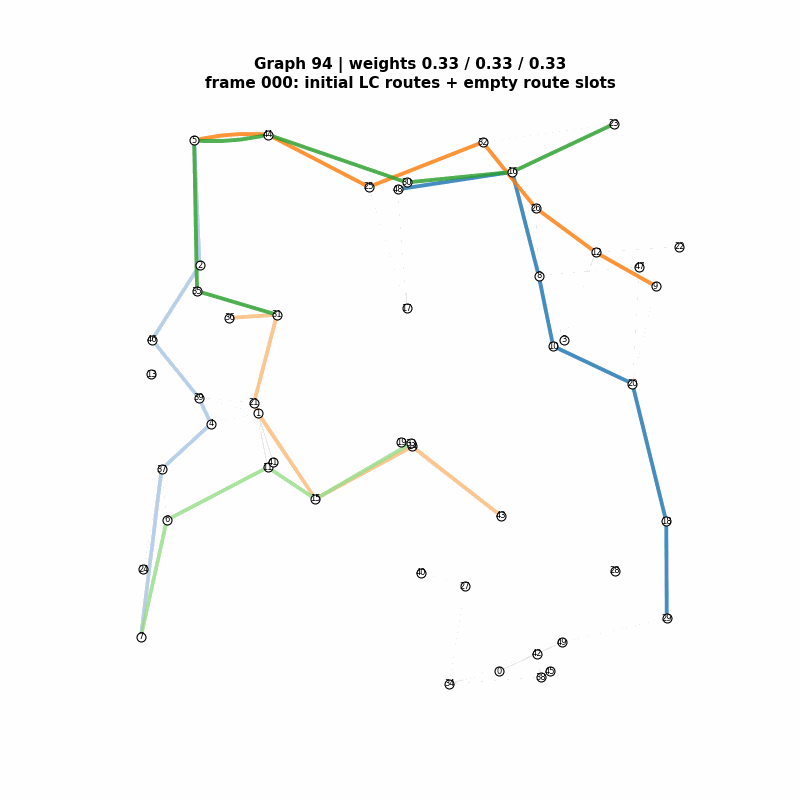

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from IPython.display import Image as IPyImage, display
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import FancyArrowPatch

from connectpt.routes_generator.improvement_learning import (
    _get_planned_current_routes,
    _make_route_context_state,
)
from connectpt.routes_generator.torch_utils import get_batch_tensor_from_routes
from connectpt.routes_generator.transit_time_estimator import (
    ROUTE_ACTION_EXTEND,
    ROUTE_ACTION_HALT,
    ROUTE_ACTION_TRIM_END,
    ROUTE_ACTION_TRIM_START,
)

GIF_GRAPH_POS = 90
GIF_GRAPH_IDX = int(VAL_INDICES[GIF_GRAPH_POS])
GIF_WEIGHTS = {
    "demand_time_weight": 0.33,
    "route_time_weight": 0.33,
    "median_connectivity_weight": 0.33,
}
GIF_FPS = 2
GIF_PATH = OUTPUT_DIR / f"{run_name}_graph_{GIF_GRAPH_IDX}_balanced_actions.gif"

ACTION_NAMES = {
    ROUTE_ACTION_EXTEND: "extend",
    ROUTE_ACTION_TRIM_START: "trim_start",
    ROUTE_ACTION_TRIM_END: "trim_end",
    ROUTE_ACTION_HALT: "halt",
}


def make_fixed_weight_dict(batch_size, weights):
    return {
        key: torch.full((batch_size,), float(value), device=device)
        for key, value in weights.items()
    }


def clean_route(route_tensor):
    if not torch.is_tensor(route_tensor):
        route_tensor = torch.as_tensor(route_tensor)
    return [int(node) for node in route_tensor.detach().cpu().tolist() if int(node) >= 0]


def action_text(action_kind, action):
    action_kind = int(action_kind)
    name = ACTION_NAMES[action_kind]
    if action_kind == ROUTE_ACTION_HALT:
        return name
    return f"{name}({int(action[0])} -> {int(action[1])})"


def undirected_edge_key(edge):
    return tuple(sorted((int(edge[0]), int(edge[1]))))


def build_edge_overlap_map(routes):
    edge_to_routes = {}
    for route_idx, route_tensor in enumerate(routes.detach().cpu()):
        route = clean_route(route_tensor)
        for edge in zip(route[:-1], route[1:]):
            edge_to_routes.setdefault(undirected_edge_key(edge), set()).add(route_idx)

    overlap_map = {}
    for edge_key, route_idxs in edge_to_routes.items():
        ordered_route_idxs = sorted(route_idxs)
        count = len(ordered_route_idxs)
        for pos, route_idx in enumerate(ordered_route_idxs):
            overlap_map[(route_idx, edge_key)] = (pos, count)
    return overlap_map


def overlapping_edge_rad(route_idx, edge, overlap_map, base_step=0.16, max_rad=0.28):
    edge_key = undirected_edge_key(edge)
    pos, count = overlap_map.get((route_idx, edge_key), (0, 1))
    if count <= 1:
        return 0.0

    centered_pos = pos - (count - 1) / 2.0
    max_centered_pos = max((count - 1) / 2.0, 1.0)
    step = min(base_step, max_rad / max_centered_pos)
    direction_sign = 1.0 if tuple(edge) == edge_key else -1.0
    return centered_pos * step * direction_sign


def draw_route_edge(ax, coords, edge, *, color, linewidth, alpha, route_idx,
                    overlap_map, linestyle="-", zorder=3):
    start, end = edge
    rad = overlapping_edge_rad(route_idx, edge, overlap_map)
    start_xy = coords[start]
    end_xy = coords[end]

    if abs(rad) < 1e-9:
        ax.plot(
            [start_xy[0], end_xy[0]],
            [start_xy[1], end_xy[1]],
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            linestyle=linestyle,
            solid_capstyle="round",
            zorder=zorder,
        )
        return

    patch = FancyArrowPatch(
        posA=start_xy,
        posB=end_xy,
        arrowstyle="-",
        connectionstyle=f"arc3,rad={rad:.4f}",
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        linestyle=linestyle,
        shrinkA=0,
        shrinkB=0,
        mutation_scale=1,
        zorder=zorder,
    )
    ax.add_patch(patch)


def draw_action_frame(ax, graph, routes, frame):
    routes = routes.detach().cpu()
    coords = graph[STOP_KEY].pos.detach().cpu().numpy()
    street_adj = graph.street_adj.detach().cpu().numpy()
    n_nodes = coords.shape[0]
    n_routes = routes.shape[0]
    colors = plt.cm.tab20(np.linspace(0, 1, max(20, n_routes)))
    overlap_map = build_edge_overlap_map(routes)

    for start in range(n_nodes):
        for end in range(start + 1, n_nodes):
            if np.isfinite(street_adj[start, end]) or np.isfinite(street_adj[end, start]):
                ax.plot(
                    [coords[start, 0], coords[end, 0]],
                    [coords[start, 1], coords[end, 1]],
                    color="lightgray",
                    linewidth=0.8,
                    alpha=0.35,
                    zorder=1,
                )

    for route_idx, route_tensor in enumerate(routes):
        route = clean_route(route_tensor)
        if len(route) < 2:
            continue
        color = colors[route_idx % len(colors)]
        is_active = route_idx == frame["route_idx"]
        linewidth = 4.2 if is_active else 2.8
        alpha = 1.0 if is_active else 0.82

        for edge in zip(route[:-1], route[1:]):
            draw_route_edge(
                ax,
                coords,
                edge,
                color=color,
                linewidth=linewidth,
                alpha=alpha,
                route_idx=route_idx,
                overlap_map=overlap_map,
                zorder=3 if not is_active else 4,
            )
        ax.scatter(
            coords[route, 0],
            coords[route, 1],
            color=[color],
            s=34 if not is_active else 52,
            edgecolor="black" if is_active else "white",
            linewidth=0.8,
            zorder=5,
        )

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=42,
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        zorder=6,
    )
    for node_idx, (x_coord, y_coord) in enumerate(coords):
        ax.text(
            x_coord,
            y_coord,
            str(node_idx),
            fontsize=6,
            ha="center",
            va="center",
            zorder=7,
        )

    ax.set_title(
        f"Graph {GIF_GRAPH_IDX} | weights 0.33 / 0.33 / 0.33\n"
        f"frame {frame['frame']:03d}: {frame['label']}",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_aspect("equal")
    ax.axis("off")


def put_route(display_routes, route_idx, route):
    display_routes = display_routes.clone()
    display_routes[:, route_idx] = -1
    route = route[route > -1].to(display_routes.device)
    if route.numel() == 0:
        return display_routes
    route_tensor = get_batch_tensor_from_routes(
        [[route]],
        display_routes.device,
        max_route_len=display_routes.shape[-1],
    )
    display_routes[:, route_idx] = route_tensor[:, 0]
    return display_routes


def collect_balanced_action_frames(graph_idx):
    batch_indices = torch.tensor([int(graph_idx)], dtype=torch.long)
    graph_batch, route_batch = make_improvement_batch(
        graphs,
        seed_routes,
        batch_indices,
        device,
        training=False,
        target_n_routes=TARGET_N_ROUTES,
    )
    weights = make_fixed_weight_dict(1, GIF_WEIGHTS)

    context_route_len = max(
        int(route_batch.shape[-1]),
        int(MAX_ROUTE_LEN),
        int(graph_batch[STOP_KEY].num_nodes),
    )
    working_route_batch = torch.full(
        (1, route_batch.shape[1], context_route_len),
        -1,
        dtype=route_batch.dtype,
        device=device,
    )
    working_route_batch[..., :route_batch.shape[-1]] = route_batch
    display_route_batch = working_route_batch.clone()
    seed_route_is_empty = (route_batch > -1).sum(dim=-1) == 0

    frames = [
        {
            "frame": 0,
            "route_idx": None,
            "step_idx": 0,
            "label": "initial LC routes + empty route slots",
            "routes": display_route_batch[0].detach().cpu(),
        }
    ]
    rows = []

    model.eval()
    frame_idx = 1
    with torch.no_grad():
        for route_idx in range(route_batch.shape[1]):
            use_sequential_context = bool(seed_route_is_empty[:, route_idx].all().item())
            context_route_batch = working_route_batch if use_sequential_context else route_batch
            route_state = _make_route_context_state(
                cost_obj,
                graph_batch,
                context_route_batch,
                route_idx,
                MIN_ROUTE_LEN,
                MAX_ROUTE_LEN,
                weights,
                invalid_directly_connected=use_sequential_context,
            )
            context_route_counts = route_state.n_finished_routes.detach().clone()
            route_state = model.setup_planning(route_state)

            for step_idx in range(MAX_ROUTE_EDIT_STEPS + 1):
                if route_state.is_done().all():
                    break

                if step_idx >= MAX_ROUTE_EDIT_STEPS:
                    step_kinds = torch.full(
                        (1,),
                        ROUTE_ACTION_HALT,
                        dtype=torch.long,
                        device=device,
                    )
                    step_actions = torch.full((1, 2), -1, dtype=torch.long, device=device)
                else:
                    step_kinds, step_actions, _, _ = model.step_route_action(
                        route_state,
                        greedy=True,
                        allow_halt=not (FORCE_NONHALT_FIRST_STEP and step_idx == 0),
                    )

                label = action_text(step_kinds[0], step_actions[0])
                route_state.apply_route_actions(step_kinds, step_actions)
                planned_route = _get_planned_current_routes(
                    route_state,
                    route_batch[:, route_idx],
                    context_route_counts,
                )[0]
                display_step_routes = put_route(
                    display_route_batch,
                    route_idx,
                    planned_route,
                )

                frames.append(
                    {
                        "frame": frame_idx,
                        "route_idx": route_idx,
                        "step_idx": step_idx + 1,
                        "label": f"R{route_idx} step {step_idx + 1}: {label}",
                        "routes": display_step_routes[0].detach().cpu(),
                    }
                )
                rows.append(
                    {
                        "frame": frame_idx,
                        "route": route_idx,
                        "step": step_idx + 1,
                        "action": label,
                        "route_nodes": " -> ".join(map(str, clean_route(planned_route))),
                    }
                )
                frame_idx += 1

                if int(step_kinds[0].item()) == ROUTE_ACTION_HALT:
                    break

            final_route = _get_planned_current_routes(
                route_state,
                route_batch[:, route_idx],
                context_route_counts,
            )[0]
            display_route_batch = put_route(display_route_batch, route_idx, final_route)
            if use_sequential_context:
                working_route_batch = put_route(working_route_batch, route_idx, final_route)

    _, seed_result, final_result, _, _, route_actions, route_action_kinds = rollout_lc_improvement(
        model,
        cost_obj,
        graph_batch,
        route_batch,
        MIN_ROUTE_LEN,
        MAX_ROUTE_LEN,
        greedy=True,
        cost_weights=weights,
        return_actions=True,
        force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
        max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
    )
    action_stats = summarize_route_action_stats(route_actions, route_action_kinds)
    return graph_batch, frames, pd.DataFrame(rows), seed_result, final_result, action_stats


graph_batch, gif_frames, gif_steps_df, gif_seed_result, gif_final_result, gif_action_stats = \
    collect_balanced_action_frames(GIF_GRAPH_IDX)

print(f"Graph:       {GIF_GRAPH_IDX}")
print(f"GIF frames:  {len(gif_frames)}")
print(f"Seed cost:   {gif_seed_result.cost.item():.4f}")
print(f"Final cost:  {gif_final_result.cost.item():.4f}")
print(f"Delta:       {(gif_seed_result.cost - gif_final_result.cost).item():.4f}")
print("Action stats:", gif_action_stats)
print(f"GIF path:    {GIF_PATH}")

fig, ax = plt.subplots(figsize=(8, 8))

def update_gif(frame_pos):
    ax.clear()
    draw_action_frame(ax, graphs[GIF_GRAPH_IDX], gif_frames[frame_pos]["routes"], gif_frames[frame_pos])
    return []

animation = FuncAnimation(
    fig,
    update_gif,
    frames=len(gif_frames),
    interval=1000 / GIF_FPS,
    blit=False,
)

try:
    animation.save(GIF_PATH, writer=PillowWriter(fps=GIF_FPS))
    plt.close(fig)
    display(IPyImage(filename=str(GIF_PATH)))
except Exception as exc:
    plt.close(fig)
    print(f"Could not save GIF with PillowWriter: {exc}")
    fig, ax = plt.subplots(figsize=(8, 8))
    draw_action_frame(ax, graphs[GIF_GRAPH_IDX], gif_frames[-1]["routes"], gif_frames[-1])
    plt.show()


## 11. Route Change Diagnostic

In [11]:
diagnostic_val = evaluate_lc_improvement(
    model,
    cost_obj,
    graphs,
    seed_routes,
    VAL_INDICES[:BATCH_SIZE],
    device,
    MIN_ROUTE_LEN,
    MAX_ROUTE_LEN,
    batch_size=BATCH_SIZE,
    force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
    target_n_routes=TARGET_N_ROUTES,
)

print("Diagnostic on one validation batch")
print(f"Changed route rate: {diagnostic_val['changed_route_rate']:.2%}")
print(f"Changed graph rate: {diagnostic_val['changed_graph_rate']:.2%}")
print(f"Cost delta:         {diagnostic_val['delta']:.4f}")

Diagnostic on one validation batch
Changed route rate: 27.60%
Changed graph rate: 75.00%
Cost delta:         0.2477


## 12. Compare Initial And Improved Routes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

from connectpt.routes_generator.citygraph_dataset import STOP_KEY
from connectpt.routes_generator.torch_utils import get_batch_tensor_from_routes
from connectpt.routes_generator.transit_time_estimator import (
    ROUTE_ACTION_HALT,
    ROUTE_ACTION_TRIM_END,
    ROUTE_ACTION_TRIM_START,
    RouteGenBatchState,
)
metric_names = [
    "cost",
    "ATT",
    "RTT",
    "$d_0$",
    "$d_1$",
    "$d_2$",
    "$d_{un}$",
    "# disconnected node pairs",
    "# stops out of bounds",
    "median_connectivity",
    "median_connectivity_weighted",
]

metric_totals = {
    name: {"initial": 0.0, "improved": 0.0, "count": 0}
    for name in metric_names
}

model.eval()
with torch.no_grad():
    eval_weights = cost_obj.get_weights(device)
    for metric_indices in VAL_INDICES.split(BATCH_SIZE):
        metric_graph_batch, metric_route_batch = make_improvement_batch(
            graphs,
            seed_routes,
            metric_indices,
            device,
            training=False,
            target_n_routes=TARGET_N_ROUTES,
        )
        _, seed_result, improved_result, _, _ = rollout_lc_improvement(
            model,
            cost_obj,
            metric_graph_batch,
            metric_route_batch,
            MIN_ROUTE_LEN,
            MAX_ROUTE_LEN,
            greedy=True,
            cost_weights=eval_weights,
            force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
            max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
        )

        seed_metrics = seed_result.get_metrics()
        improved_metrics = improved_result.get_metrics()
        for metric_name in metric_names:
            initial_tensor = seed_metrics.get(metric_name)
            improved_tensor = improved_metrics.get(metric_name)
            if initial_tensor is None or improved_tensor is None:
                continue
            initial_tensor = initial_tensor.detach().float().cpu()
            improved_tensor = improved_tensor.detach().float().cpu()
            metric_totals[metric_name]["initial"] += float(initial_tensor.sum())
            metric_totals[metric_name]["improved"] += float(improved_tensor.sum())
            metric_totals[metric_name]["count"] += int(initial_tensor.numel())

comparison_rows = []
for metric_name in metric_names:
    metric_count = metric_totals[metric_name]["count"]
    if metric_count == 0:
        continue
    initial_value = metric_totals[metric_name]["initial"] / metric_count
    improved_value = metric_totals[metric_name]["improved"] / metric_count
    comparison_rows.append(
        {
            "metric": metric_name,
            "initial": initial_value,
            "improved": improved_value,
            "delta": improved_value - initial_value,
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

WEIGHT_SCENARIOS = [
    {
        "name": "balanced",
        "title": "All weights = 0.33",
        "demand_time_weight": 0.33,
        "route_time_weight": 0.33,
        "median_connectivity_weight": 0.33,
    },
    {
        "name": "passenger",
        "title": "ATT weight = 1.0",
        "demand_time_weight": 1.0,
        "route_time_weight": 0.0,
        "median_connectivity_weight": 0.0,
    },
    {
        "name": "operator",
        "title": "RTT weight = 1.0",
        "demand_time_weight": 0.0,
        "route_time_weight": 1.0,
        "median_connectivity_weight": 0.0,
    },
    {
        "name": "connectivity",
        "title": "Connectivity weight = 1.0",
        "demand_time_weight": 0.0,
        "route_time_weight": 0.0,
        "median_connectivity_weight": 1.0,
    },
]


def make_eval_weight_dict(scenario, batch_size):
    return {
        "demand_time_weight": torch.full(
            (batch_size,),
            float(scenario["demand_time_weight"]),
            device=device,
        ),
        "route_time_weight": torch.full(
            (batch_size,),
            float(scenario["route_time_weight"]),
            device=device,
        ),
        "median_connectivity_weight": torch.full(
            (batch_size,),
            float(scenario["median_connectivity_weight"]),
            device=device,
        ),
    }


def _clone_cost_weights(cost_weights):
    return {
        key: value.clone() if torch.is_tensor(value) else value
        for key, value in cost_weights.items()
    }


def build_seed_state(graph_batch, route_batch, cost_weights):
    state = RouteGenBatchState(
        graph_batch,
        cost_obj,
        int(route_batch.shape[1]),
        MIN_ROUTE_LEN,
        MAX_ROUTE_LEN,
        cost_weights=_clone_cost_weights(cost_weights),
    )
    state.add_new_routes(route_batch)
    return state


def _match_cost_weight_batch(weight_value, state):
    if not torch.is_tensor(weight_value):
        weight_value = torch.full(
            (state.batch_size,),
            float(weight_value),
            device=state.device,
        )
    elif weight_value.ndim == 0:
        weight_value = weight_value.expand(state.batch_size)
    elif weight_value.shape[0] > state.batch_size:
        weight_value = weight_value[:state.batch_size]
    return weight_value


def compute_cost_breakdown(state, result):
    demand_time_weight = _match_cost_weight_batch(
        state.cost_weights.get("demand_time_weight", cost_obj.demand_time_weight),
        state,
    )
    route_time_weight = _match_cost_weight_batch(
        state.cost_weights.get("route_time_weight", cost_obj.route_time_weight),
        state,
    )
    median_connectivity_weight = _match_cost_weight_batch(
        state.cost_weights.get(
            "median_connectivity_weight",
            cost_obj.median_connectivity_weight,
        ),
        state,
    )
    constraint_weight = _match_cost_weight_batch(
        cost_obj.constraint_violation_weight,
        state,
    )

    time_normalizer = state.drive_times.flatten(1, 2).max(1).values
    n_routes = state.n_routes_to_plan
    frac_uncovered = result.n_disconnected_demand_edges / state.n_demand_edges
    if state.max_route_len is None:
        denom = n_routes * state.max_route_len
    else:
        denom = n_routes * state.min_route_len
    denom = denom.clone()
    denom[denom == 0] = 1

    served_demand = result.total_demand - result.unserved_demand
    demand_cost = result.mean_demand_time * served_demand + \
        result.unserved_demand * time_normalizer * 2
    demand_cost /= result.total_demand
    route_cost = result.total_route_time
    median_connectivity = result.median_connectivity_weighted \
        if cost_obj.use_weighted_connectivity else result.median_connectivity
    demand_cost = demand_cost / time_normalizer
    route_cost = route_cost / (time_normalizer * n_routes + 1e-6)
    median_connectivity = median_connectivity / time_normalizer

    demand_component = demand_cost * demand_time_weight
    route_component = route_cost * route_time_weight
    connectivity_component = median_connectivity_weight * median_connectivity
    uncovered_penalty = (
        frac_uncovered + 0.1 * (frac_uncovered > 0)
    ) * constraint_weight
    frac_stops_oob = result.n_stops_oob / denom
    oob_penalty = (
        frac_stops_oob + 0.1 * (frac_stops_oob > 0)
    ) * constraint_weight

    cost_without_oob = demand_component + route_component + \
        connectivity_component + uncovered_penalty
    cost_with_oob = cost_without_oob + oob_penalty

    return {
        "cost_reported": result.cost.detach().float().cpu(),
        "cost_without_oob": cost_without_oob.detach().float().cpu(),
        "cost_with_oob": cost_with_oob.detach().float().cpu(),
        "demand_component": demand_component.detach().float().cpu(),
        "route_component": route_component.detach().float().cpu(),
        "connectivity_component": connectivity_component.detach().float().cpu(),
        "uncovered_penalty": uncovered_penalty.detach().float().cpu(),
        "oob_penalty": oob_penalty.detach().float().cpu(),
        "n_stops_oob": result.n_stops_oob.detach().float().cpu(),
        "n_disconnected_pairs": result.n_disconnected_demand_edges.detach().float().cpu(),
    }


def scalar_from_breakdown(breakdown, key):
    value = breakdown[key]
    if torch.is_tensor(value):
        value = value.reshape(-1)[0].item()
    return float(value)


def format_breakdown_line(prefix, breakdown):
    return (
        f"{prefix}: d={scalar_from_breakdown(breakdown, 'demand_component'):.2f} "
        f"r={scalar_from_breakdown(breakdown, 'route_component'):.2f} "
        f"mc={scalar_from_breakdown(breakdown, 'connectivity_component'):.2f} "
        f"unc={scalar_from_breakdown(breakdown, 'uncovered_penalty'):.2f} "
        f"oob={scalar_from_breakdown(breakdown, 'oob_penalty'):.2f}"
    )


def count_trim_actions_by_graph(route_action_kinds, batch_size):
    trim_counts = torch.zeros(batch_size, dtype=torch.long)
    for kinds_for_route in route_action_kinds:
        if kinds_for_route is None:
            continue

        kinds_for_route = kinds_for_route.detach().cpu()
        ended = torch.zeros(batch_size, dtype=torch.bool)
        for step_idx in range(kinds_for_route.shape[1]):
            active = ~ended
            if not active.any():
                break

            step_kinds = kinds_for_route[:, step_idx]
            is_trim = (
                (step_kinds == ROUTE_ACTION_TRIM_START)
                | (step_kinds == ROUTE_ACTION_TRIM_END)
            )
            trim_counts += (active & is_trim).long()
            ended = ended | (active & (step_kinds == ROUTE_ACTION_HALT))
    return trim_counts


def slice_route_action_data(route_actions, route_action_kinds, local_pos):
    sliced_actions = [
        actions[local_pos:local_pos + 1].detach().cpu()
        for actions in route_actions
    ]
    sliced_kinds = [
        None if kinds is None else kinds[local_pos:local_pos + 1].detach().cpu()
        for kinds in route_action_kinds
    ]
    return sliced_actions, sliced_kinds


def run_weight_scenario_on_batch(batch_indices, scenario):
    graph_batch, route_batch = make_improvement_batch(
        graphs,
        seed_routes,
        batch_indices,
        device,
        training=False,
        target_n_routes=TARGET_N_ROUTES,
    )
    scenario_weights = make_eval_weight_dict(
        scenario,
        int(batch_indices.numel()),
    )
    with torch.no_grad():
        rollout_output = rollout_lc_improvement(
            model,
            cost_obj,
            graph_batch,
            route_batch,
            MIN_ROUTE_LEN,
            MAX_ROUTE_LEN,
            greedy=True,
            cost_weights=scenario_weights,
            return_actions=True,
            force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
            max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
        )
    return graph_batch, route_batch, rollout_output


def run_single_graph_scenario(graph_idx, scenario):
    batch_indices = torch.tensor([int(graph_idx)], dtype=torch.long)
    graph_batch, route_batch, rollout_output = run_weight_scenario_on_batch(
        batch_indices,
        scenario,
    )
    scenario_weights = make_eval_weight_dict(scenario, 1)
    seed_state = build_seed_state(graph_batch, route_batch, scenario_weights)
    improved_state, seed_result, final_result = rollout_output[:3]
    route_actions = rollout_output[5]
    route_action_kinds = rollout_output[6]
    action_stats = summarize_route_action_stats(route_actions, route_action_kinds)
    improved_routes = get_batch_tensor_from_routes(
        improved_state.routes,
        device,
    )[0].detach().cpu()
    seed_breakdown = compute_cost_breakdown(seed_state, seed_result)
    final_breakdown = compute_cost_breakdown(improved_state, final_result)
    return {
        "scenario": scenario,
        "graph_idx": int(graph_idx),
        "initial_routes": route_batch[0].detach().cpu(),
        "improved_routes": improved_routes,
        "seed_cost": float(seed_result.cost.detach().cpu()[0]),
        "final_cost": float(final_result.cost.detach().cpu()[0]),
        "seed_breakdown": seed_breakdown,
        "final_breakdown": final_breakdown,
        "action_stats": action_stats,
    }


def find_trim_validation_graph(scenario):
    best_graph_idx = None
    best_trim_count = 0

    for batch_indices in VAL_INDICES.split(BATCH_SIZE):
        _, _, rollout_output = run_weight_scenario_on_batch(
            batch_indices,
            scenario,
        )
        route_action_kinds = rollout_output[6]
        trim_counts = count_trim_actions_by_graph(
            route_action_kinds,
            int(batch_indices.numel()),
        )

        batch_best_trim_count = int(trim_counts.max().item())
        if batch_best_trim_count > best_trim_count:
            best_pos = int(trim_counts.argmax().item())
            best_graph_idx = int(batch_indices[best_pos])
            best_trim_count = batch_best_trim_count

    return best_graph_idx, best_trim_count


balanced_scenario = WEIGHT_SCENARIOS[0]
plot_graph_idx, balanced_trim_count = find_trim_validation_graph(balanced_scenario)
if plot_graph_idx is None:
    plot_graph_idx = int(VAL_INDICES[90])
    print("No trim actions found with balanced weights; showing the first validation graph.")
else:
    print(
        "Selected validation graph "
        f"{plot_graph_idx} with {balanced_trim_count} trim actions "
        "under balanced weights."
    )

scenario_results = [
    run_single_graph_scenario(plot_graph_idx, scenario)
    for scenario in WEIGHT_SCENARIOS
]
initial_routes = scenario_results[0]["initial_routes"]

scenario_rows = []
for result in scenario_results:
    scenario = result["scenario"]
    stats = result["action_stats"]
    scenario_rows.append(
        {
            "scenario": scenario["name"],
            "demand_weight": scenario["demand_time_weight"],
            "route_weight": scenario["route_time_weight"],
            "connectivity_weight": scenario["median_connectivity_weight"],
            "seed_cost": result["seed_cost"],
            "final_cost": result["final_cost"],
            "seed_cost_with_oob": scalar_from_breakdown(result["seed_breakdown"], "cost_with_oob"),
            "final_cost_with_oob": scalar_from_breakdown(result["final_breakdown"], "cost_with_oob"),
            "delta": result["seed_cost"] - result["final_cost"],
            "seed_demand": scalar_from_breakdown(result["seed_breakdown"], "demand_component"),
            "seed_route": scalar_from_breakdown(result["seed_breakdown"], "route_component"),
            "seed_conn": scalar_from_breakdown(result["seed_breakdown"], "connectivity_component"),
            "seed_uncovered": scalar_from_breakdown(result["seed_breakdown"], "uncovered_penalty"),
            "seed_oob": scalar_from_breakdown(result["seed_breakdown"], "oob_penalty"),
            "seed_oob_stops": scalar_from_breakdown(result["seed_breakdown"], "n_stops_oob"),
            "final_demand": scalar_from_breakdown(result["final_breakdown"], "demand_component"),
            "final_route": scalar_from_breakdown(result["final_breakdown"], "route_component"),
            "final_conn": scalar_from_breakdown(result["final_breakdown"], "connectivity_component"),
            "final_uncovered": scalar_from_breakdown(result["final_breakdown"], "uncovered_penalty"),
            "final_oob": scalar_from_breakdown(result["final_breakdown"], "oob_penalty"),
            "final_oob_stops": scalar_from_breakdown(result["final_breakdown"], "n_stops_oob"),
            "extend": stats["extend_count"],
            "trim_start": stats["trim_start_count"],
            "trim_end": stats["trim_end_count"],
            "halt": stats["halt_count"],
            "avg_actions": stats["avg_actions_per_route"],
        }
    )

display(pd.DataFrame(scenario_rows))


def get_first_route_set(routes):
    if isinstance(routes, torch.Tensor):
        routes = routes.detach().cpu()
    else:
        routes = get_batch_tensor_from_routes(routes).detach().cpu()
    if routes.ndim == 3:
        return routes[0]
    return routes


def route_to_list(route_tensor):
    return [int(node) for node in route_tensor.tolist() if int(node) >= 0]


def route_edge_list(route):
    return [(route[idx], route[idx + 1]) for idx in range(len(route) - 1)]


def undirected_edge_key(edge):
    return tuple(sorted(edge))


def draw_street_graph(ax, coords, street_adj):
    n_nodes = coords.shape[0]
    for start in range(n_nodes):
        for end in range(start + 1, n_nodes):
            if np.isfinite(street_adj[start, end]) or np.isfinite(street_adj[end, start]):
                ax.plot(
                    [coords[start, 0], coords[end, 0]],
                    [coords[start, 1], coords[end, 1]],
                    color="lightgray",
                    linewidth=1.0,
                    alpha=0.35,
                    zorder=1,
                )


def build_edge_overlap_map(*route_sets):
    edge_to_routes = {}
    for route_set in route_sets:
        if route_set is None:
            continue
        route_set = get_first_route_set(route_set)
        for route_idx, route_tensor in enumerate(route_set):
            route = route_to_list(route_tensor)
            for edge in route_edge_list(route):
                edge_to_routes.setdefault(undirected_edge_key(edge), set()).add(route_idx)

    overlap_map = {}
    for edge_key, route_idxs in edge_to_routes.items():
        ordered_route_idxs = sorted(route_idxs)
        count = len(ordered_route_idxs)
        for pos, route_idx in enumerate(ordered_route_idxs):
            overlap_map[(route_idx, edge_key)] = (pos, count)
    return overlap_map


def overlapping_edge_rad(route_idx, edge, overlap_map, base_step=0.16, max_rad=0.28):
    edge_key = undirected_edge_key(edge)
    pos, count = overlap_map.get((route_idx, edge_key), (0, 1))
    if count <= 1:
        return 0.0

    centered_pos = pos - (count - 1) / 2.0
    max_centered_pos = max((count - 1) / 2.0, 1.0)
    step = min(base_step, max_rad / max_centered_pos)
    direction_sign = 1.0 if tuple(edge) == edge_key else -1.0
    return centered_pos * step * direction_sign


def plot_edge(ax, coords, edge, *, color, linewidth, alpha, route_idx,
              overlap_map, linestyle="-", zorder=3):
    start, end = edge
    start_xy = coords[start]
    end_xy = coords[end]
    rad = overlapping_edge_rad(route_idx, edge, overlap_map)

    if abs(rad) < 1e-9:
        ax.plot(
            [start_xy[0], end_xy[0]],
            [start_xy[1], end_xy[1]],
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            linestyle=linestyle,
            solid_capstyle="round",
            zorder=zorder,
        )
        return

    patch = FancyArrowPatch(
        posA=start_xy,
        posB=end_xy,
        arrowstyle="-",
        connectionstyle=f"arc3,rad={rad:.4f}",
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        linestyle=linestyle,
        shrinkA=0,
        shrinkB=0,
        mutation_scale=1,
        zorder=zorder,
    )
    ax.add_patch(patch)


def plot_edges(ax, coords, edges, *, color, linewidth, alpha, route_idx,
               overlap_map, linestyle="-", zorder=3):
    for edge in edges:
        plot_edge(
            ax,
            coords,
            edge,
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            route_idx=route_idx,
            overlap_map=overlap_map,
            linestyle=linestyle,
            zorder=zorder,
        )


ROUTE_COLOR_CYCLE = np.asarray(plt.get_cmap("tab20").colors)


def route_colors_for_n(n_routes):
    if n_routes <= 0:
        return ROUTE_COLOR_CYCLE[:0]
    color_indices = np.arange(n_routes) % len(ROUTE_COLOR_CYCLE)
    return ROUTE_COLOR_CYCLE[color_indices]


def route_colors_for(routes):
    routes = get_first_route_set(routes)
    return route_colors_for_n(routes.shape[0])


def route_nodes_text(route):
    return " -> ".join(map(str, route)) if route else "empty"


def draw_route_sequence_table(ax, routes, title="Route sequences"):
    routes = get_first_route_set(routes)
    colors = route_colors_for(routes)
    rows = []
    cell_colours = []

    for route_idx, route_tensor in enumerate(routes):
        route = route_to_list(route_tensor)
        rows.append([f"R{route_idx}", route_nodes_text(route)])
        route_color = colors[route_idx % len(colors)]
        label_color = route_color if route else (0.86, 0.86, 0.86, 1.0)
        cell_colours.append([label_color, (1.0, 1.0, 1.0, 1.0)])

    ax.axis("off")
    ax.set_title(title, fontsize=9, pad=2)
    table = ax.table(
        cellText=rows,
        cellColours=cell_colours,
        colLabels=["route", "nodes"],
        colColours=[(0.94, 0.94, 0.94, 1.0), (0.94, 0.94, 0.94, 1.0)],
        colWidths=[0.16, 0.84],
        cellLoc="left",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1.0, 1.15)

    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor("0.75")
        cell.set_linewidth(0.6)
        if row_idx == 0:
            cell.get_text().set_fontweight("bold")
        elif col_idx == 0:
            route_idx = row_idx - 1
            route = route_to_list(routes[route_idx])
            cell.get_text().set_color("white" if route else "0.35")
            cell.get_text().set_fontweight("bold")
        else:
            cell.get_text().set_fontfamily("monospace")
    return table


def summarize_route_changes(routes, reference_routes):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    n_routes = max(routes.shape[0], reference_routes.shape[0])
    summary = {
        "changed_routes": 0,
        "added_edges": 0,
        "removed_edges": 0,
        "added_stops": 0,
        "removed_stops": 0,
    }

    for route_idx in range(n_routes):
        route = route_to_list(routes[route_idx]) if route_idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[route_idx]) if route_idx < reference_routes.shape[0] else []

        route_edges = {undirected_edge_key(edge) for edge in route_edge_list(route)}
        reference_edges = {undirected_edge_key(edge) for edge in route_edge_list(reference)}
        route_nodes = set(route)
        reference_nodes = set(reference)

        added_edges = route_edges - reference_edges
        removed_edges = reference_edges - route_edges
        added_stops = route_nodes - reference_nodes
        removed_stops = reference_nodes - route_nodes

        if added_edges or removed_edges or added_stops or removed_stops:
            summary["changed_routes"] += 1
        summary["added_edges"] += len(added_edges)
        summary["removed_edges"] += len(removed_edges)
        summary["added_stops"] += len(added_stops)
        summary["removed_stops"] += len(removed_stops)

    return summary


def plot_plain_route_set(ax, routes, graph, title, subtitle=None):
    routes = get_first_route_set(routes)
    coords = graph[STOP_KEY].pos.detach().cpu().numpy()
    street_adj = graph.street_adj.detach().cpu().numpy()
    draw_street_graph(ax, coords, street_adj)

    colors = route_colors_for(routes)
    overlap_map = build_edge_overlap_map(routes)
    for route_idx, route_tensor in enumerate(routes):
        route = route_to_list(route_tensor)
        if len(route) < 2:
            continue
        color = colors[route_idx % len(colors)]
        plot_edges(
            ax,
            coords,
            route_edge_list(route),
            color=color,
            linewidth=3.2,
            alpha=0.95,
            route_idx=route_idx,
            overlap_map=overlap_map,
            zorder=3,
        )

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=55, zorder=5)
    for node_idx, (x_coord, y_coord) in enumerate(coords):
        ax.text(
            x_coord,
            y_coord,
            str(node_idx),
            fontsize=7,
            color="white",
            ha="center",
            va="center",
            zorder=6,
        )

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


def plot_route_diff(ax, routes, reference_routes, graph, title, subtitle=None):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    coords = graph[STOP_KEY].pos.detach().cpu().numpy()
    street_adj = graph.street_adj.detach().cpu().numpy()
    draw_street_graph(ax, coords, street_adj)

    colors = route_colors_for_n(max(routes.shape[0], reference_routes.shape[0]))
    n_routes = max(routes.shape[0], reference_routes.shape[0])
    overlap_map = build_edge_overlap_map(routes, reference_routes)

    for route_idx in range(n_routes):
        route = route_to_list(routes[route_idx]) if route_idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[route_idx]) if route_idx < reference_routes.shape[0] else []
        color = colors[route_idx % len(colors)]

        route_edges_in_order = route_edge_list(route)
        reference_edges_in_order = route_edge_list(reference)
        route_edge_keys = {undirected_edge_key(edge) for edge in route_edges_in_order}
        reference_edge_keys = {undirected_edge_key(edge) for edge in reference_edges_in_order}

        shared_edges = [
            edge for edge in route_edges_in_order
            if undirected_edge_key(edge) in reference_edge_keys
        ]
        added_edges = [
            edge for edge in route_edges_in_order
            if undirected_edge_key(edge) not in reference_edge_keys
        ]
        removed_edges = [
            edge for edge in reference_edges_in_order
            if undirected_edge_key(edge) not in route_edge_keys
        ]

        if removed_edges:
            plot_edges(
                ax,
                coords,
                removed_edges,
                color="dimgray",
                linewidth=2.2,
                alpha=0.85,
                linestyle="--",
                route_idx=route_idx,
                overlap_map=overlap_map,
                zorder=2,
            )
        if shared_edges:
            plot_edges(
                ax,
                coords,
                shared_edges,
                color=color,
                linewidth=2.0,
                alpha=0.35,
                route_idx=route_idx,
                overlap_map=overlap_map,
                zorder=3,
            )
        if added_edges:
            plot_edges(
                ax,
                coords,
                added_edges,
                color=color,
                linewidth=4.0,
                alpha=0.95,
                route_idx=route_idx,
                overlap_map=overlap_map,
                zorder=4,
            )

        route_nodes = set(route)
        reference_nodes = set(reference)
        shared_nodes = sorted(route_nodes & reference_nodes)
        added_nodes = sorted(route_nodes - reference_nodes)
        removed_nodes = sorted(reference_nodes - route_nodes)

        if shared_nodes:
            ax.scatter(
                coords[shared_nodes, 0],
                coords[shared_nodes, 1],
                s=20,
                facecolors="white",
                edgecolors=[color],
                linewidths=1.0,
                zorder=5,
            )
        if added_nodes:
            ax.scatter(
                coords[added_nodes, 0],
                coords[added_nodes, 1],
                s=40,
                c=[color],
                edgecolors="black",
                linewidths=0.5,
                zorder=6,
            )
        if removed_nodes:
            ax.scatter(
                coords[removed_nodes, 0],
                coords[removed_nodes, 1],
                s=45,
                c="crimson",
                marker="x",
                linewidths=1.4,
                zorder=6,
            )

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=45, alpha=0.65, zorder=4)
    for node_idx, (x_coord, y_coord) in enumerate(coords):
        ax.text(
            x_coord,
            y_coord,
            str(node_idx),
            fontsize=7,
            color="white",
            ha="center",
            va="center",
            zorder=7,
        )

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


plot_graph = graphs[plot_graph_idx]
initial_nonempty_routes = int(((initial_routes > -1).sum(dim=-1) > 1).sum().item())
fig = plt.figure(figsize=(24, 22), constrained_layout=True)
grid = fig.add_gridspec(
    4,
    3,
    height_ratios=[4.2, 1.15, 4.2, 1.15],
)
plot_axes = []
table_axes = []
for plot_row, table_row in [(0, 1), (2, 3)]:
    for col_idx in range(3):
        plot_axes.append(fig.add_subplot(grid[plot_row, col_idx]))
        table_axes.append(fig.add_subplot(grid[table_row, col_idx]))

plot_plain_route_set(
    plot_axes[0],
    initial_routes,
    plot_graph,
    "Initial LC routes",
    subtitle=(
        f"balanced cost={scenario_results[0]['seed_cost']:.3f}, "
        f"with_oob={scalar_from_breakdown(scenario_results[0]['seed_breakdown'], 'cost_with_oob'):.3f}\n"
        f"{format_breakdown_line('seed cmp', scenario_results[0]['seed_breakdown'])}\n"
        f"routes={initial_nonempty_routes}"
    ),
)
draw_route_sequence_table(table_axes[0], initial_routes, "Initial route nodes")

for ax, table_ax, result in zip(plot_axes[1:], table_axes[1:], scenario_results):
    scenario = result["scenario"]
    stats = result["action_stats"]
    change_summary = summarize_route_changes(result["improved_routes"], initial_routes)
    improved_routes = get_first_route_set(result["improved_routes"])
    improved_nonempty_routes = int(((improved_routes > -1).sum(dim=-1) > 1).sum().item())
    subtitle = (
        f"cost {result['seed_cost']:.3f} -> {result['final_cost']:.3f}, "
        f"with_oob {scalar_from_breakdown(result['seed_breakdown'], 'cost_with_oob'):.3f}"
        f" -> {scalar_from_breakdown(result['final_breakdown'], 'cost_with_oob'):.3f}, "
        f"routes={improved_nonempty_routes}\n"
        f"{format_breakdown_line('final cmp', result['final_breakdown'])}\n"
        f"changed={change_summary['changed_routes']}, "
        f"+seg={change_summary['added_edges']}, -seg={change_summary['removed_edges']}, "
        f"+stop={change_summary['added_stops']}, -stop={change_summary['removed_stops']}\n"
        f"actions: ext={stats['extend_count']}, "
        f"trim_s={stats['trim_start_count']}, trim_e={stats['trim_end_count']}"
    )
    plot_route_diff(
        ax,
        result["improved_routes"],
        initial_routes,
        plot_graph,
        scenario["title"],
        subtitle=subtitle,
    )
    draw_route_sequence_table(
        table_ax,
        result["improved_routes"],
        f"{scenario['name']} route nodes",
    )

plot_axes[-1].axis("off")
table_axes[-1].axis("off")
style_handles = [
    Line2D([0], [0], color="dimgray", lw=2.2, linestyle="--", label="initial-only segment / shortened away"),
    Line2D([0], [0], color="tab:blue", lw=2.0, alpha=0.35, label="shared segment"),
    Line2D([0], [0], color="tab:blue", lw=4.0, label="new / extended segment"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="tab:blue", markersize=7, lw=0, label="added stop"),
    Line2D([0], [0], marker="x", color="crimson", markersize=7, lw=0, label="removed stop"),
]
fig.legend(handles=style_handles, loc="lower center", bbox_to_anchor=(0.5, -0.005), ncol=5, frameon=True)
fig.suptitle(f"Validation graph {plot_graph_idx}: initial LC and greedy improvement diffs under fixed cost weights")
plt.show()


## 13. Seed-vs-Agent Objective Mismatch


In [ ]:
PURE_SCENARIO_BY_NAME = {
    scenario["name"]: scenario
    for scenario in WEIGHT_SCENARIOS
    if sum(
        float(scenario[key]) > 0.999
        for key in (
            "demand_time_weight",
            "route_time_weight",
            "median_connectivity_weight",
        )
    ) == 1
}

SEED_DATA_SCENARIO_NAME = "passenger"
AGENT_EVAL_SCENARIO_NAME = "operator"
MISMATCH_SAMPLE_LIMIT = 64


def scenario_weight_tuple(scenario):
    return (
        float(scenario["demand_time_weight"]),
        float(scenario["route_time_weight"]),
        float(scenario["median_connectivity_weight"]),
    )


def select_graph_indices_for_seed_scenario(metadata_df, candidate_indices, scenario):
    candidate_set = set(int(idx) for idx in torch.as_tensor(candidate_indices).tolist())
    dw, rw, cw = scenario_weight_tuple(scenario)
    mask = metadata_df["graph_index"].isin(candidate_set)
    mask &= np.isclose(metadata_df["demand_time_weight"].fillna(-1.0).to_numpy(dtype=float), dw)
    mask &= np.isclose(metadata_df["route_time_weight"].fillna(-1.0).to_numpy(dtype=float), rw)
    mask &= np.isclose(metadata_df["median_connectivity_weight"].fillna(-1.0).to_numpy(dtype=float), cw)
    selected = metadata_df.loc[mask, "graph_index"].to_numpy(dtype=np.int64)
    return torch.as_tensor(selected, dtype=torch.long)


def evaluate_fixed_weight_scenario(indices, scenario):
    indices = torch.as_tensor(indices, dtype=torch.long)
    seed_costs = []
    final_costs = []
    route_change_masks = []
    action_counts = il._new_action_count_totals()

    for batch_indices in indices.split(BATCH_SIZE):
        _, route_batch, rollout_output = run_weight_scenario_on_batch(
            batch_indices,
            scenario,
        )
        state, seed_result, final_result, _, _, route_actions, route_action_kinds = rollout_output
        batch_action_stats = summarize_route_action_stats(route_actions, route_action_kinds)
        il._merge_action_stats(action_counts, batch_action_stats)

        final_routes = get_batch_tensor_from_routes(state.routes, device).detach().cpu()
        seed_costs.append(seed_result.cost.detach().cpu())
        final_costs.append(final_result.cost.detach().cpu())
        route_change_masks.append(
            il._route_change_mask(route_batch.detach().cpu(), final_routes).cpu()
        )

    seed_costs = torch.cat(seed_costs)
    final_costs = torch.cat(final_costs)
    route_change_mask = torch.cat(route_change_masks)
    action_stats = il._finalize_action_stats(action_counts)
    return {
        "n_graphs": int(indices.numel()),
        "seed_cost": seed_costs.mean().item(),
        "final_cost": final_costs.mean().item(),
        "delta": (seed_costs - final_costs).mean().item(),
        "win_rate": (final_costs < seed_costs).float().mean().item(),
        "changed_route_rate": route_change_mask.float().mean().item(),
        "changed_graph_rate": route_change_mask.any(dim=1).float().mean().item(),
        "action_stats": action_stats,
    }


seed_data_scenario = PURE_SCENARIO_BY_NAME[SEED_DATA_SCENARIO_NAME]
agent_eval_scenario = PURE_SCENARIO_BY_NAME[AGENT_EVAL_SCENARIO_NAME]
comparison_indices = select_graph_indices_for_seed_scenario(
    LC_ROUTE_METADATA,
    VAL_INDICES,
    seed_data_scenario,
)
if MISMATCH_SAMPLE_LIMIT is not None and len(comparison_indices) > MISMATCH_SAMPLE_LIMIT:
    comparison_indices = comparison_indices[:MISMATCH_SAMPLE_LIMIT]

if len(comparison_indices) == 0:
    raise ValueError(
        f"No validation graphs found for seed scenario {SEED_DATA_SCENARIO_NAME}"
    )

matched_result = evaluate_fixed_weight_scenario(comparison_indices, seed_data_scenario)
mismatched_result = evaluate_fixed_weight_scenario(comparison_indices, agent_eval_scenario)

comparison_rows = []
for label, scenario, result in [
    ("matched", seed_data_scenario, matched_result),
    ("mismatched", agent_eval_scenario, mismatched_result),
]:
    stats = result["action_stats"]
    comparison_rows.append(
        {
            "comparison": label,
            "scenario": scenario["name"],
            "title": scenario["title"],
            "demand_weight": scenario["demand_time_weight"],
            "route_weight": scenario["route_time_weight"],
            "connectivity_weight": scenario["median_connectivity_weight"],
            "n_graphs": result["n_graphs"],
            "seed_cost": result["seed_cost"],
            "final_cost": result["final_cost"],
            "delta": result["delta"],
            "win_rate": result["win_rate"],
            "changed_route_rate": result["changed_route_rate"],
            "changed_graph_rate": result["changed_graph_rate"],
            "extend": stats["extend_count"],
            "trim_start": stats["trim_start_count"],
            "trim_end": stats["trim_end_count"],
            "halt": stats["halt_count"],
            "avg_actions": stats["avg_actions_per_route"],
        }
    )

print(
    "Comparing validation graphs whose LC seeds were generated with "
    f"{seed_data_scenario['title']} against the agent evaluated with "
    f"{agent_eval_scenario['title']}."
)
print(f"Compared graphs: {len(comparison_indices)}")
display(pd.DataFrame(comparison_rows))


## 14. Random Route Sanity Check


Graph: 884
Random seed cost:  6.9606
Improved cost:     6.9606
Delta:             0.0000
Action stats: {'extend_count': 0, 'trim_start_count': 0, 'trim_end_count': 0, 'halt_count': 12, 'total_count': 12, 'route_plan_count': 12, 'trim_count': 0, 'edit_count': 0, 'extend_rate': 0.0, 'trim_start_rate': 0.0, 'trim_end_rate': 0.0, 'halt_rate': 1.0, 'trim_rate': 0.0, 'edit_rate': 0.0, 'avg_actions_per_route': 1.0}


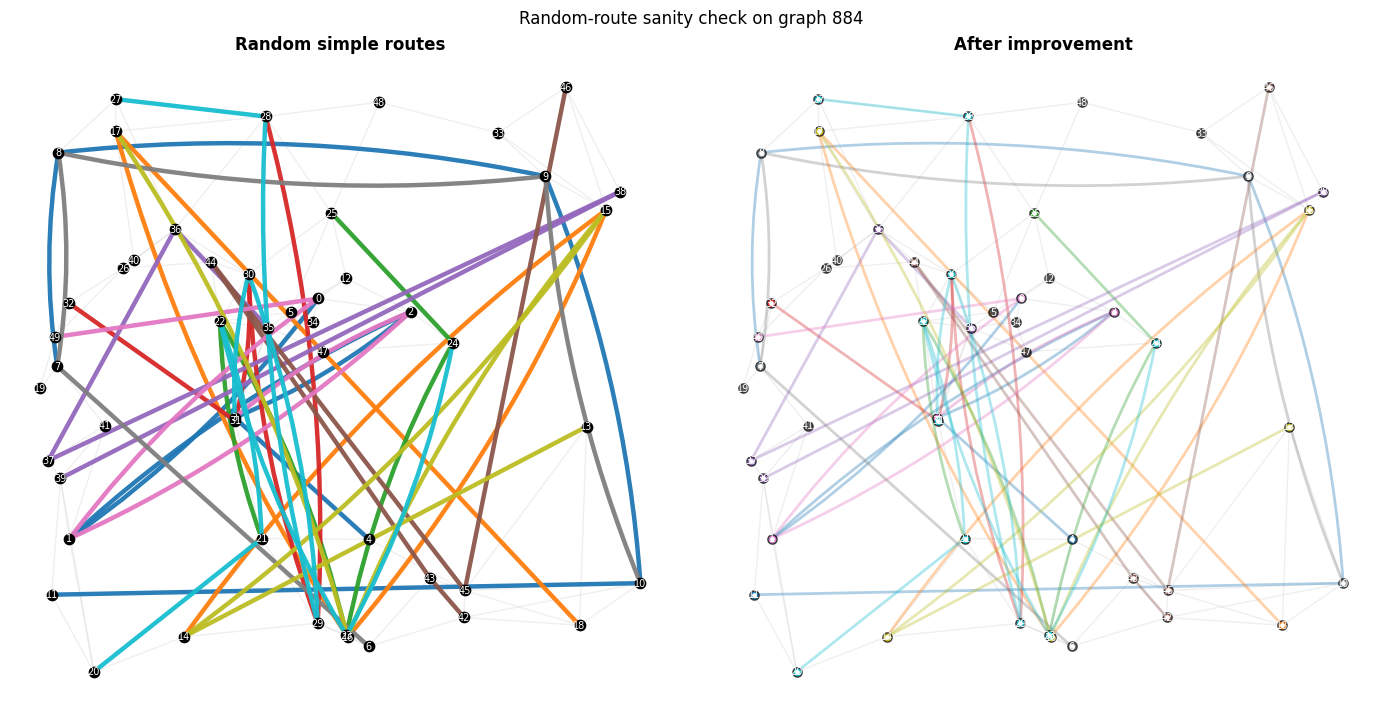

In [ ]:
import pandas as pd

from connectpt.routes_generator.torch_utils import get_batch_tensor_from_routes

RANDOM_ROUTE_GRAPH_POS = 0
RANDOM_ROUTE_LEN = 5
RANDOM_ROUTE_STRIDE = 7

random_graph_idx = int(VAL_INDICES[RANDOM_ROUTE_GRAPH_POS])
random_graph = graphs[random_graph_idx]
n_nodes = int(random_graph[STOP_KEY].num_nodes)
n_random_routes = int(TARGET_N_ROUTES or seed_routes.shape[1])

random_route_list = []
for route_idx in range(n_random_routes):
    start = (route_idx * RANDOM_ROUTE_STRIDE) % n_nodes
    route = [
        (start + offset) % n_nodes
        for offset in range(RANDOM_ROUTE_LEN)
    ]
    random_route_list.append(route)

random_seed_routes = get_batch_tensor_from_routes(
    [random_route_list],
    device,
)
random_graph_batch, _ = make_improvement_batch(
    graphs,
    seed_routes,
    torch.tensor([random_graph_idx], dtype=torch.long),
    device,
    training=False,
    target_n_routes=TARGET_N_ROUTES,
)

model.eval()
with torch.no_grad():
    random_state, random_seed_result, random_final_result, _, _, \
        random_actions, random_action_kinds = rollout_lc_improvement(
            model,
            cost_obj,
            random_graph_batch,
            random_seed_routes,
            MIN_ROUTE_LEN,
            MAX_ROUTE_LEN,
            greedy=True,
            cost_weights=cost_obj.get_weights(device),
            return_actions=True,
            force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
            max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
        )

random_improved_routes = get_batch_tensor_from_routes(
    random_state.routes,
    device,
)[0].detach().cpu()
random_initial_routes = random_seed_routes[0].detach().cpu()

print(f"Graph: {random_graph_idx}")
print(f"Random seed cost:  {random_seed_result.cost.item():.4f}")
print(f"Improved cost:     {random_final_result.cost.item():.4f}")
print(f"Delta:             {(random_seed_result.cost - random_final_result.cost).item():.4f}")
print("Action stats:", summarize_route_action_stats(random_actions, random_action_kinds))

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
plot_plain_route_set(
    axes[0],
    random_initial_routes,
    random_graph,
    "Random simple routes",
)
plot_route_diff(
    axes[1],
    random_improved_routes,
    random_initial_routes,
    random_graph,
    "After improvement",
)
fig.suptitle(f"Random-route sanity check on graph {random_graph_idx}")
plt.show()
